In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Merging Datasets

In [ ]:
visits = pd.read_csv('New-370 data - all (2).csv')

In [ ]:
economics = pd.read_csv("New-370 data - Economics.csv")

In [ ]:
## grouping visits by the year and park 

byYearPark = visits.groupby(by=["Year","Park Name", 'Park Code','State']).sum().reset_index()
byYearPark = byYearPark.drop(columns=['Month'])
byYearPark = byYearPark[byYearPark['Year']<2025]
#byYearPark.head()

In [ ]:
## merging visits and economics together + getting rid of some extra columns 
visits_economics = pd.merge(byYearPark, economics, left_on=['Year', 'Park Code'], right_on=['Year', 'Code'], how='inner')
visits_economics = visits_economics.drop(columns = ["Name", "Recreation Visits", "Code"])

In [ ]:
visits_economics.head()

,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
0,2015,Acadia National Park,ACAD,ME,2811184,47100,14452151,47100,0,135000,...,0,1233,8343,0,176670,247910.8,3878.0,102112.7,172526.1,304623.5
1,2015,Arches National Park,ARCH,UT,1399247,0,5420170,0,0,27158,...,0,1208,6005,0,50933,162718.2,2711.0,67949.5,122729.0,216319.6
2,2015,Badlands National Park,BADL,SD,989354,65911,4531214,32956,9474,4627,...,39444,1445,215,0,56062,62209.2,1015.0,24363.7,40138.3,77537.9
3,2015,Big Bend National Park,BIBE,TX,381747,2364,9504644,7092,50747,53963,...,9643,32435,33945,0,205153,33426.3,503.0,11340.1,20658.1,37168.8
4,2015,Biscayne National Park,BISC,FL,508164,0,1672449,0,0,1860,...,0,0,4305,0,6165,31927.3,450.0,17612.1,27499.2,44346.6


In [ ]:
visits_economics['State'].unique()

array(['ME ', 'UT', 'SD', 'TX', 'FL', 'CO', 'NM', 'CA', 'SC', 'OR', 'OH',
       'AK', 'MO', 'MT', 'AZ', 'WY', 'NV', 'TN/NC', 'HI', 'AR', 'IN',
       'MI', 'KY', 'WA', 'VA', 'ND', 'VI', 'MN'], dtype=object)

# EDA

### Summary statistics 

In [ ]:
visits_economics.describe()

,Year,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
count,600.000000,6.000000e+02,6.000000e+02,6.000000e+02,6.000000e+02,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02,6.000000e+02,600.000000,6.000000e+02,6.000000e+02,6.000000e+02
mean,2019.500000,1.412268e+06,3.957252e+05,1.146075e+07,2.654515e+05,43075.733333,38985.461667,24215.833333,17556.211667,22607.528333,7796.353333,450.735000,1.539616e+05,1.562969e+05,2095.968333,7.349316e+04,1.240750e+05,2.121814e+05
std,2.874678,1.946318e+06,1.465275e+06,1.982571e+07,8.673624e+05,131819.308223,69691.341451,42701.273377,78471.395285,48376.570396,15154.846949,1712.680532,2.914938e+05,2.461739e+05,3402.079113,1.229229e+05,2.038467e+05,3.469924e+05
min,2015.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,2017.000000,2.720400e+05,0.000000e+00,1.390753e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,382.500000,0.000000,0.000000,9.645250e+03,2.798528e+04,351.750000,1.159450e+04,1.999650e+04,3.429625e+04
50%,2019.500000,6.659130e+05,7.650500e+03,3.675749e+06,1.577800e+04,0.000000,6184.500000,3752.500000,0.000000,3525.000000,824.500000,0.000000,4.233600e+04,6.187200e+04,823.500000,2.771950e+04,4.843900e+04,8.237100e+04
75%,2022.000000,1.704201e+06,6.363475e+04,1.093750e+07,8.404750e+04,18488.750000,49748.500000,29430.000000,0.000000,27069.500000,8300.250000,0.000000,1.550908e+05,1.565978e+05,2126.250000,7.253425e+04,1.261542e+05,2.104223e+05
max,2024.000000,1.416155e+07,1.123478e+07,1.035739e+08,5.617391e+06,938418.000000,588701.000000,376744.000000,616089.000000,337790.000000,89472.000000,12925.000000,2.062671e+06,2.198538e+06,33748.000000,1.267581e+06,2.000786e+06,3.397905e+06


In [ ]:
visits.describe()

,Year,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,7920.000000,7.920000e+03,7.920000e+03,7.920000e+03,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000
mean,2020.000000,1.183488e+05,3.309108e+04,9.550774e+05,22233.509091,3622.548359,3232.742424,2031.939141,1477.166288,1858.321465,652.305177,36.792045,12849.848611
std,3.162477,2.011076e+05,1.264970e+05,2.170515e+06,77496.278277,14044.597612,8441.268642,5061.824709,10890.371389,5461.584677,1637.493130,185.225800,34159.094912
min,2015.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,1.072150e+04,0.000000e+00,5.204350e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.000000
50%,2020.000000,4.537750e+04,4.460000e+02,1.931590e+05,600.000000,0.000000,46.000000,0.000000,0.000000,84.000000,0.000000,0.000000,1307.000000
75%,2023.000000,1.282242e+05,5.797750e+03,7.211620e+05,6150.000000,897.250000,1852.500000,1520.000000,0.000000,675.000000,335.000000,0.000000,9261.500000
max,2025.000000,1.739720e+06,1.334690e+06,2.021239e+07,685776.000000,153527.000000,121937.000000,78060.000000,163452.000000,62848.000000,14436.000000,6165.000000,360221.000000


### Top 5 Years with most recreation visitors 

In [ ]:
visits.groupby(by='Year').sum().drop(columns =["Month", "Park Name", "Park Code","State"]).sort_values('Recreation Visitors', ascending = False).head()

,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
Year,,,,,,,,,,,,
2024,91186076,24624441,689328121,16946841,2934501,2319208,1625650,1049104,1291922,505069,31513,9774561
2025,89961848,24646266,687763596,16818501,2845143,2212043,1563458,1165430,1153389,488445,20952,9393865
2023,89671691,24507664,704825539,16908622,2605545,2138044,1509415,1025902,1323345,518283,29331,9095365
2021,89614755,22200135,693100034,15347671,2081419,2063240,1374656,1025340,1512831,415743,24156,8438590
2019,88726379,24018185,731746982,15893952,2909336,2509363,1486627,973338,1292999,444026,21449,9580719


### Top 5 Parks with most recreation visitors 

In [ ]:

top_5_parks=visits_economics.groupby('Park Name').agg({'Recreation Visitors':'mean', 'Economic\nOutput ($)':'mean','Jobs Supported':'mean'})
top_5_parks =top_5_parks.sort_values('Recreation Visitors', ascending = False)
top_5_parks=top_5_parks.head()
top_5_parks



,Recreation Visitors,Economic\nOutput ($),Jobs Supported
Park Name,,,
Great Smoky Mountains National Park,12201767.8,1916503.65,19143.8
Grand Canyon National Park,5191443.5,955292.63,9641.2
Zion National Park,4415042.2,582198.10,6217.9
Rocky Mountain National Park,4268191.9,575466.77,5070.3
Yellowstone National Park,4180922.4,696350.65,7354.3


In [ ]:
top_5_eco =  visits_economics[visits_economics['Park Name'].isin(['Great Smoky Mountains National Park', 'Grand Canyon National Park','Zion National Park	', 'Rocky Mountain National Park','Yellowstone National Park' ])]

### Top 5 parks with the most Jobs Supported

In [ ]:
top_5_parks_jobs = visits_economics[visits_economics['Park Name'].isin(['Great Smoky Mountains National Park', 'Grand Canyon National Park', 'Grand Teton National Park','Yellowstone National Park', 'Yosemite National Park'])]
top_5_parks_jobs

,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
23,2015,Grand Canyon National Park,GRCA,AZ,5520736,62876,87141657,62876,540000,207490,...,25289,293866,32709,0,1200582,584890.9,8897.0,301914.6,502940.4,813705.8
24,2015,Grand Teton National Park,GRTE,WY,3149921,1497965,21758918,1497965,210538,0,...,385770,33798,1132,0,631240,560394.4,8862.0,258250.2,412894.3,728987.8
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
57,2015,Yellowstone National Park,YELL,WY,4097710,1156118,82016845,711795,552940,104149,...,584979,44898,11715,0,1368514,493620.9,7737.0,224826.5,361876.3,638574.7
58,2015,Yosemite National Park,YOSE,CA,4150217,155081,78505877,3993223,938418,588701,...,0,211966,39214,0,2062671,449080.8,6887.0,207730.7,348826.2,593693.7
83,2016,Grand Canyon National Park,GRCA,AZ,5969811,60435,94286572,60435,600307,206626,...,24257,330703,40891,0,1291386,648170.9,9779.0,334219.8,556633.8,904315.7
84,2016,Grand Teton National Park,GRTE,WY,3270076,1552896,20161755,1552896,196577,0,...,297084,36206,979,0,530846,597290.5,9365.0,274744.8,439366.4,779479.8
87,2016,Great Smoky Mountains National Park,GRSM,TN/NC,11312786,11215231,83859719,5607616,11493,190574,...,0,109349,24777,0,447876,942731.8,14673.0,426908.8,745508.1,1277787.6
117,2016,Yellowstone National Park,YELL,WY,4257177,1198856,84411927,743728,579227,101639,...,583068,44663,10986,0,1388575,524319.8,8156.0,238536.4,383908.1,680381.8
118,2016,Yosemite National Park,YOSE,CA,5028868,188246,77763403,4771376,743546,490431,...,0,216989,51542,0,1879252,520629.1,7883.0,238955.1,401329.8,686339.5


,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
23,2015,Grand Canyon National Park,GRCA,AZ,5520736,62876,87141657,62876,540000,207490,...,25289,293866,32709,0,1200582,584890.9,8897.0,301914.6,502940.4,813705.8
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
47,2015,Rocky Mountain National Park,ROMO,CO,4155916,8750,28840877,26250,0,124254,...,0,46301,12604,0,244086,268391.4,4144.0,152167.6,246198.3,408311.0
57,2015,Yellowstone National Park,YELL,WY,4097710,1156118,82016845,711795,552940,104149,...,584979,44898,11715,0,1368514,493620.9,7737.0,224826.5,361876.3,638574.7
59,2015,Zion National Park,ZION,UT,3648846,21900,25028289,5475,82853,133528,...,0,24655,18962,0,333781,202198.4,2823.0,104418.6,172318.2,274562.8


### Great smoky Mountains Visits

In [ ]:
# filtering for GSM
GSM = visits_economics[visits['Park Name'].isin(['Great Smoky Mountains National Park'])]
GSM.head()


,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
87,2016,Great Smoky Mountains National Park,GRSM,TN/NC,11312786,11215231,83859719,5607616,11493,190574,...,0,109349,24777,0,447876,942731.8,14673.0,426908.8,745508.1,1277787.6
147,2017,Great Smoky Mountains National Park,GRSM,TN/NC,11338893,10396268,83343604,5198137,11160,160464,...,0,104352,22285,0,408357,922947.1,13942.0,405780.5,695842.3,1237735.0
207,2018,Great Smoky Mountains National Park,GRSM,TN/NC,11421200,10544377,83657339,5272190,11163,152167,...,0,97593,20105,0,394678,953130.0,13737.0,434943.0,743083.0,1288291.0
267,2019,Great Smoky Mountains National Park,GRSM,TN/NC,12547743,10544367,91203583,5272185,10955,155409,...,0,94569,18828,0,393300,1054815.0,15176.0,482218.0,824057.0,1427790.0


In [ ]:
# finding the mean values of the differnt visit types 
pd.pivot_table(GSM,values = ["Recreation Visitors","Non-Recreation Visitors","Concession Lodging","Tent Campers","RV Campers","Concession Camping","Backcountry Campers","Misc Campers","Non-Recreation Overnight Stays"], index = ["Park Name"], aggfunc="mean")


,Backcountry Campers,Concession Camping,Concession Lodging,Misc Campers,Non-Recreation Overnight Stays,Non-Recreation Visitors,RV Campers,Recreation Visitors,Tent Campers
Park Name,,,,,,,,,
Great Smoky Mountains National Park,95327.8,0.0,10607.3,24742.9,0.0,10711707.3,132650.2,12201767.8,179343.7


In [ ]:
# creating a new df with the visits 
GSM_visits = pd.DataFrame({"Visit type": ["Recreation Visitors","Non-Recreation Visitors","Concession Lodging","Tent Campers","RV Campers","Concession Camping","Backcountry Campers","Misc Campers","Non-Recreation Overnight Stays"], "Total": [12201767.8	,10711707.3, 10607.3, 179343.7, 132650.2, 0.0, 95327.8, 24742.9, 0.0]})	 
GSM_visits = GSM_visits.drop([0, 1, 8])
GSM_visits = GSM_visits.sort_values("Total", ascending = False)
GSM_visits


,Visit type,Total
3,Tent Campers,179343.7
4,RV Campers,132650.2
6,Backcountry Campers,95327.8
7,Misc Campers,24742.9
2,Concession Lodging,10607.3
5,Concession Camping,0.0


### GSM Economics

In [ ]:
pd.pivot_table(GSM,values = ["Visitor\nSpending ($)","Jobs Supported","Labor Income ($)","Value Added ($)","Economic\nOutput ($)"], index = ["Park Name"], aggfunc="mean")


,Economic\nOutput ($),Jobs Supported,Labor Income ($),Value Added ($),Visitor\nSpending ($)
Park Name,,,,,
Great Smoky Mountains National Park,1916503.65,19143.8,673434.7,1124212.54,1341456.64


### Top 5 states

In [ ]:
#finding the top 5 states with most economic output
visits_economics.groupby(['State']).agg({'Recreation Visitors':'mean', 'Economic\nOutput ($)':'mean'}).sort_values('Economic\nOutput ($)', ascending = False).head()


,Recreation Visitors,Economic\nOutput ($)
State,,
TN/NC,1.220177e+07,1.916504e+06
WY,3.773470e+06,7.628075e+05
ME,3.514865e+06,5.242401e+05
MT,2.846475e+06,4.402187e+05
AZ,2.235024e+06,3.643716e+05


In [ ]:
#filtering out those states
top_5_states = visits_economics[visits_economics['State'].isin(["TN/NC", "WY", "MT","AZ",'ME '])]
top_5_states = top_5_states.groupby(['State', 'Park Name'])["Economic\nOutput ($)"].mean().reset_index()
top_5_states = top_5_states.sort_values('State', ascending = False)
top_5_states

,State,Park Name,Economic\nOutput ($)
6,WY,Grand Teton National Park,829264.41
7,WY,Yellowstone National Park,696350.65
5,TN/NC,Great Smoky Mountains National Park,1916503.65
4,MT,Glacier National Park,440218.66
3,ME,Acadia National Park,524240.06
0,AZ,Grand Canyon National Park,955292.63
1,AZ,Petrified Forest National Park,44841.64
2,AZ,Saguaro National Park,92980.42


### Last 5 states 

In [ ]:
visits_economics.groupby(['State']).agg({'Recreation Visitors':'mean', 'Economic\nOutput ($)':'mean'}).sort_values('Economic\nOutput ($)', ascending = False).tail()


,Recreation Visitors,Economic\nOutput ($)
State,,
TX,333993.8,33929.21
MN,233752.7,24691.14
NV,141646.4,11383.59
SC,172749.7,11294.62
MI,23961.6,8204.54


In [ ]:
bottom_5_states = visits_economics[visits_economics['State'].isin(["TX", "MN", "NV","SC",'MI'])]
bottom_5_states = bottom_5_states.groupby(['State', 'Park Name'])["Economic\nOutput ($)"].mean().reset_index()
bottom_5_states = bottom_5_states.sort_values('State', ascending = False)
bottom_5_states

,State,Park Name,Economic\nOutput ($)
4,TX,Big Bend National Park,48088.65
5,TX,Guadalupe Mountains National Park,19769.77
3,SC,Congaree National Park,11294.62
2,NV,Great Basin National Park,11383.59
1,MN,Voyageurs National Park,24691.14
0,MI,Isle Royale National Park,8204.54


# Graphs

In [ ]:
# setting the theme 

sns.set_theme(palette='gist_earth')
sns.set_style("whitegrid")
sns.color_palette("gist_earth", 6)

[(0.09408431928011998, 0.25456763098682095, 0.4747997187719709),
 (0.19002743319550042, 0.5042304347826086, 0.49565724681625223),
 (0.25661406784936197, 0.5855013377926422, 0.32284437777281283),
 (0.5107321752862218, 0.6620551820728292, 0.32917535903993705),
 (0.724172627277075, 0.7035188948306594, 0.37379467833956326),
 (0.8342929845025828, 0.6922737254901962, 0.5786758598521377)]

Text(0.5, 1.0, 'National Parks with the Most Recreation Visits per Year')

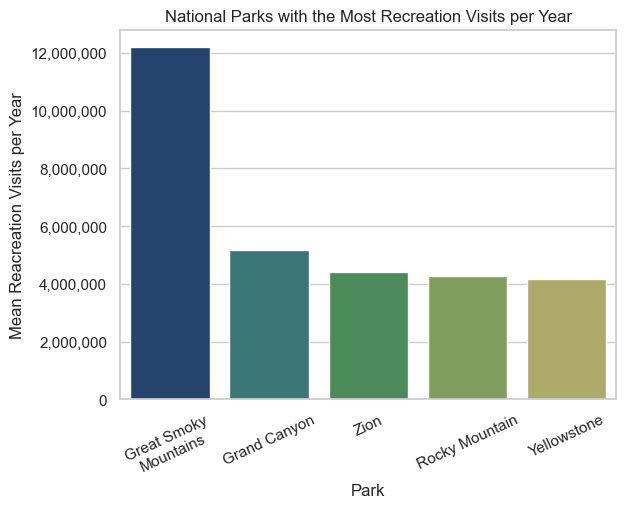

In [ ]:
 
plt1 = sns.barplot(data = top_5_parks, x='Park Name', y='Recreation Visitors', errorbar=None, hue = "Park Name")

# X axis 
plt1.set_xticks(range(5))
plt1.set_xticklabels(labels = ['Great Smoky\nMountains', "Grand Canyon", 'Zion','Rocky Mountain','Yellowstone'], rotation=25)

# Y axis
ticks = [0,2000000,4000000,6000000,8000000,10000000,12000000]
plt1.set_yticks(ticks)
plt1.set_yticklabels(["0", "2,000,000", "4,000,000", "6,000,000", "8,000,000", "10,000,000", "12,000,000"])

# Titles
plt1.set(xlabel='Park', ylabel='Mean Reacreation Visits per Year')
plt.title("National Parks with the Most Recreation Visits per Year")


Text(0.5, 1.0, 'Economic Output vs Recreation Visits')

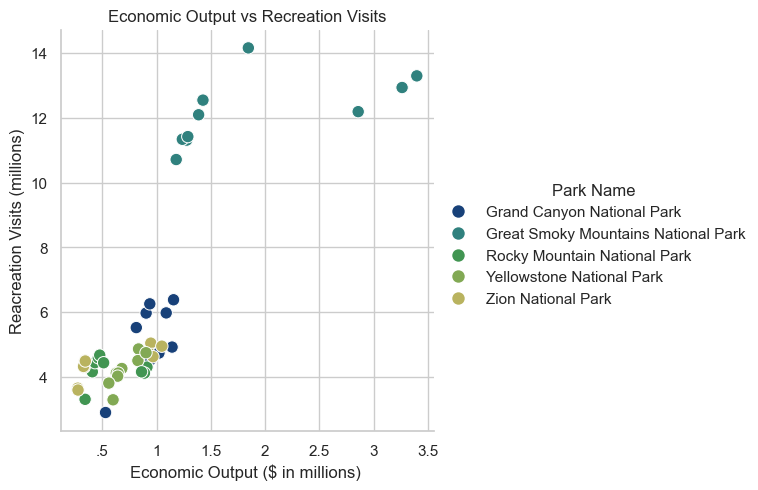

In [ ]:
plt2 = sns.relplot(data = top_5_eco, x='Economic\nOutput ($)', y='Recreation Visitors', hue = 'Park Name', s=80)

# X axis
ticksx = [500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000]
xlabels = ['.5', '1', '1.5', '2', '2.5', '3', '3.5']
plt.xticks ( ticks=ticksx, labels=xlabels)


# Y axis
ticksy = [4000000, 6000000, 8000000, 10000000, 12000000, 14000000] 
ylabels = [4, 6, 8,10,12,14] 
plt.yticks ( ticks=ticksy, labels=ylabels)

#Titles
plt2.set(xlabel='Economic Output ($ in millions) ', ylabel='Reacreation Visits (millions)')
plt.title('Economic Output vs Recreation Visits')

Text(0.5, 1.0, 'Great Smokey Mountains Recreational Visit Types')

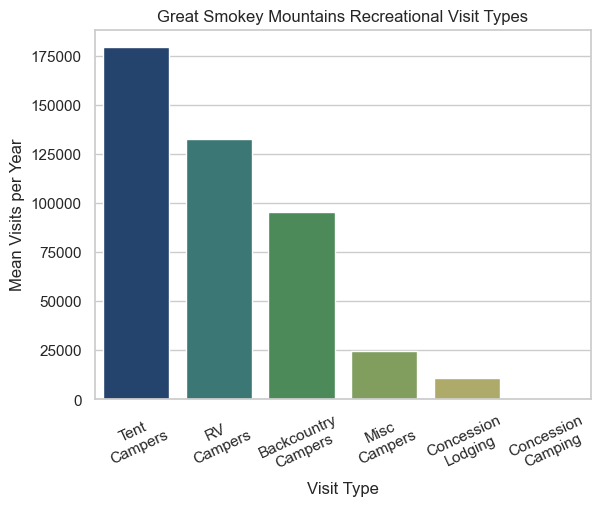

In [ ]:
plt3 = sns.barplot(data = GSM_visits, x='Visit type', y='Total', hue = 'Visit type', errorbar=None, palette='gist_earth')
sns.set_style("whitegrid")

# X axis
plt3.set_xticks(range(6))
plt3.set_xticklabels(labels = ['Tent\nCampers', 'RV\nCampers', 'Backcountry\nCampers', 'Misc\nCampers', 'Concession\nLodging','Concession\nCamping'], rotation=25)

# Titles
plt3.set(xlabel='Visit Type', ylabel='Mean Visits per Year')
plt.title("Great Smokey Mountains Recreational Visit Types")


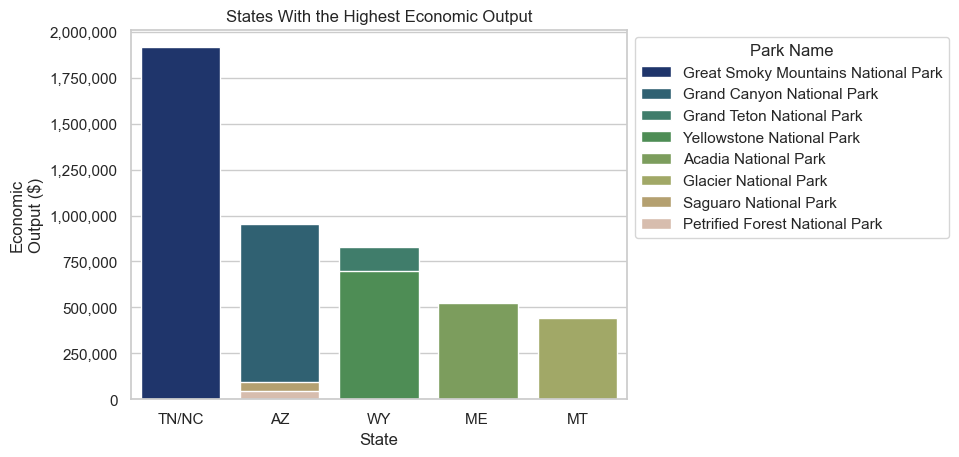

In [ ]:
# Sorting values
top_5_states = top_5_states.sort_values("Economic\nOutput ($)", ascending = False)

plt4 = sns.barplot(data=top_5_states, x = 'State', y = "Economic\nOutput ($)", errorbar=None, hue='Park Name', dodge = False,palette='gist_earth', legend = 'full')

#Y axis
ticks = [0,250000, 500000, 750000,1000000, 1250000,1500000,1750000,2000000]
plt4.set_yticks(ticks)
plt4.set_yticklabels(['0','250,000', '500,000', '750,000','1,000,000', '1,250,000','1,500,000','1,750,000','2,000,000'])

# Title + legend 
plt.title("States With the Highest Economic Output")
sns.move_legend(plt4, "upper left", bbox_to_anchor=(1, 1))


Text(0.5, 1.0, 'Parks With the Most Jobs Supported')

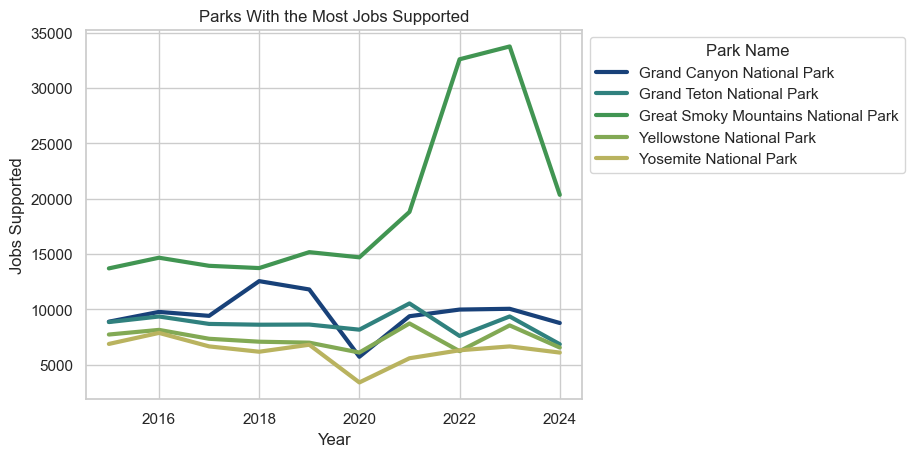

In [ ]:

plt5 = sns.lineplot(data = top_5_parks_jobs, x='Year', y='Jobs Supported', errorbar=None, hue = "Park Name", linewidth=3)

# Title + legend
sns.move_legend(plt5, "upper left", bbox_to_anchor=(1, 1))
plt.title("Parks With the Most Jobs Supported")



Text(0.5, 1.0, 'States With the Lowest Economic Output')

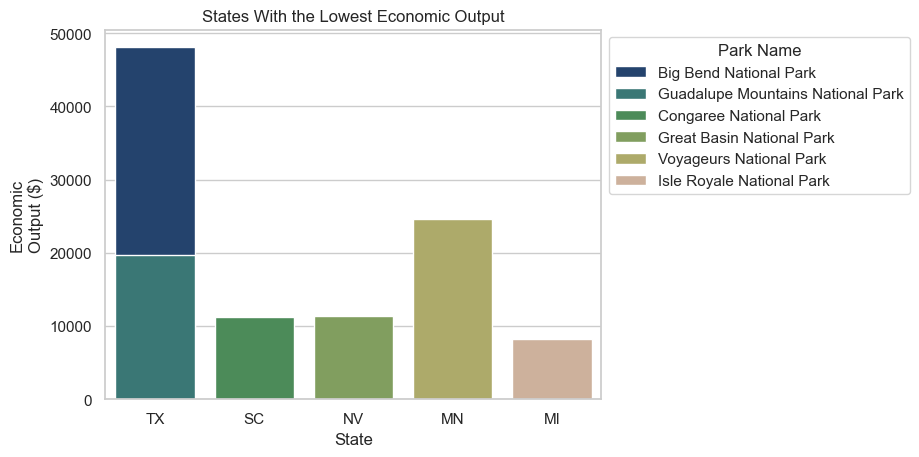

In [ ]:

plt6 = sns.barplot(data=bottom_5_states, x = 'State', y = "Economic\nOutput ($)", errorbar=None, hue='Park Name', dodge = False,palette='gist_earth', legend = 'full')

# Title + legend
sns.move_legend(plt6, "upper left", bbox_to_anchor=(1, 1))
plt.title("States With the Lowest Economic Output")

In [ ]:
#sns.pairplot(visits_economics, hue="Park Name")